# Exploratory Data Analysis of Base Datasets

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import numpy as np

sys.path.append(str(Path().resolve().parents[0]))

# Local src

from src.df_info import df_info

print('Done')

Done


In [25]:
path_csv_base = '../data/02_processed/cleaned_retail.csv'
df_base = pd.read_csv(path_csv_base)

In [26]:
df_base['invoice_date'] = pd.to_datetime(df_base['invoice_date'])
df_base['invoice_date'].isnull().sum()

np.int64(0)

In [27]:
df_info(df_base)

============================== Head ==============================
  invoice stock_code                          description  quantity  \
0  489434      85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434     79323P                   PINK CHERRY LIGHTS        12   
2  489434     79323W                  WHITE CHERRY LIGHTS        12   
3  489434      22041          RECORD FRAME 7" SINGLE SIZE        48   
4  489434      21232       STRAWBERRY CERAMIC TRINKET BOX        24   

         invoice_date  price  customer_id         country  revenue  
0 2009-12-01 07:45:00   6.95        13085  United Kingdom     83.4  
1 2009-12-01 07:45:00   6.75        13085  United Kingdom     81.0  
2 2009-12-01 07:45:00   6.75        13085  United Kingdom     81.0  
3 2009-12-01 07:45:00   2.10        13085  United Kingdom    100.8  
4 2009-12-01 07:45:00   1.25        13085  United Kingdom     30.0  
============================== Tail ==============================
       invoice stock_code

- the records for year 2009 are only since start of Dec, so only 1 month recorded;

In [28]:
df_base['year'] = df_base['invoice_date'].dt.year
df_base['month'] = df_base['invoice_date'].dt.month
print(df_base.columns)
df_base

Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date',
       'price', 'customer_id', 'country', 'revenue', 'year', 'month'],
      dtype='object')


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue,year,month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12
...,...,...,...,...,...,...,...,...,...,...,...
793750,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,2011,12
793751,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011,12
793752,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12
793753,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12


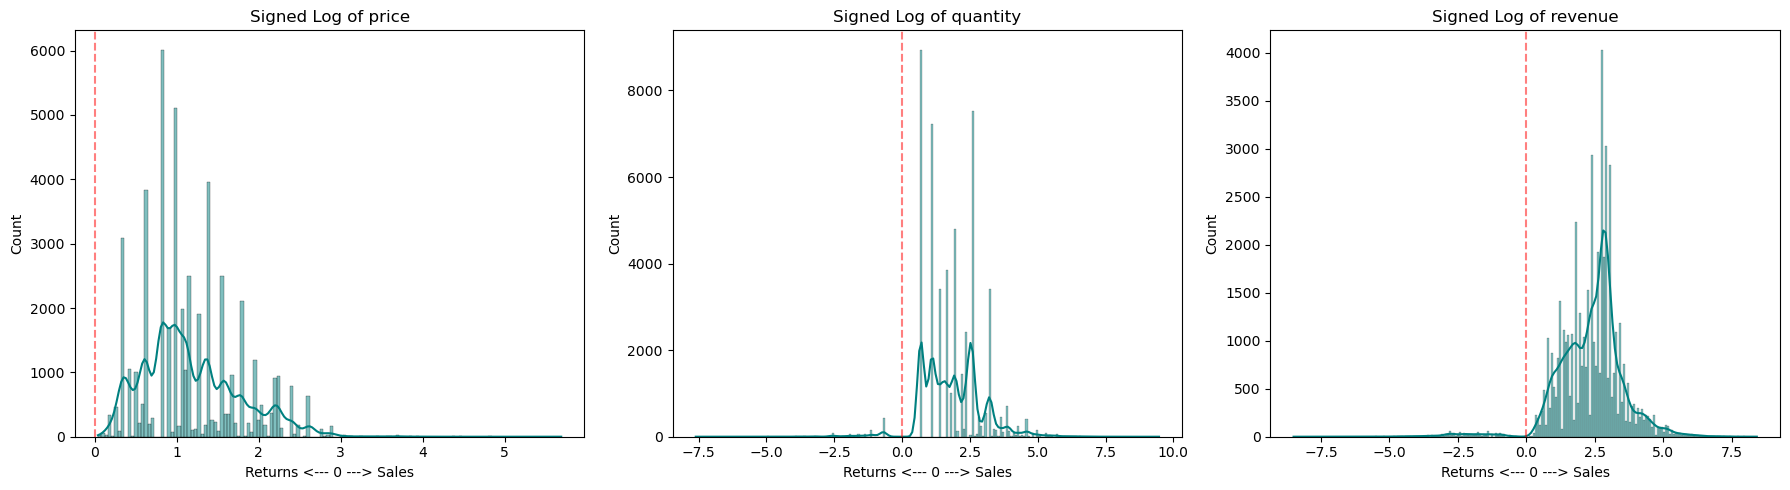

In [29]:
dist_cols = ['price', 'quantity', 'revenue']
df_sample = df_base[dist_cols].sample(n=50000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(dist_cols):
    log_data = np.sign(df_sample[col]) * np.log1p(df_sample[col].abs()) 
    
    sns.histplot(log_data, kde=True, ax=axes[i], color='teal')
    
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
    
    axes[i].set_title(f"Signed Log of {col}")
    axes[i].set_xlabel("Returns <--- 0 ---> Sales")

plt.tight_layout()
plt.show()

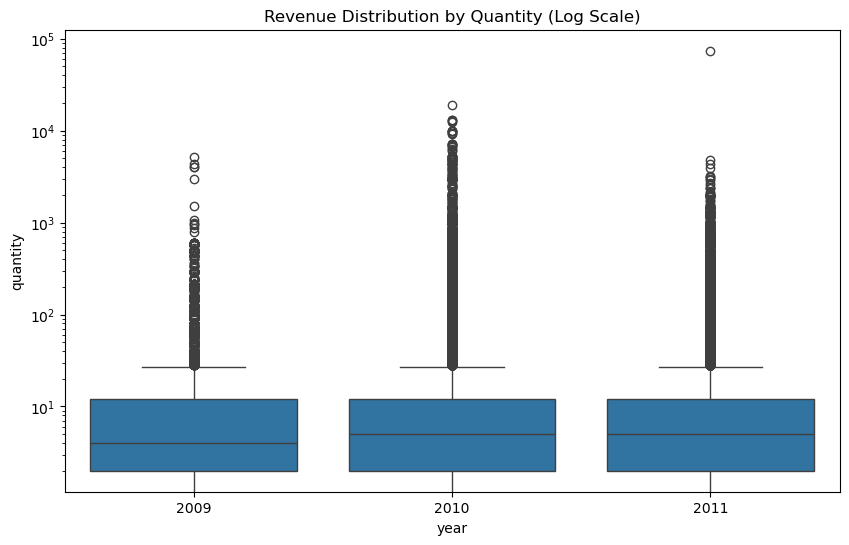

In [30]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='year', y='quantity', data=df_base)

ax.set_yscale("log") 

plt.title('Revenue Distribution by Quantity (Log Scale)')
plt.show()

- see the consistency in order sizes across years (50% of all is 2-12 units per order);
- 2010 has spike of high volume order compared to 2009 (1 month) and 2011;

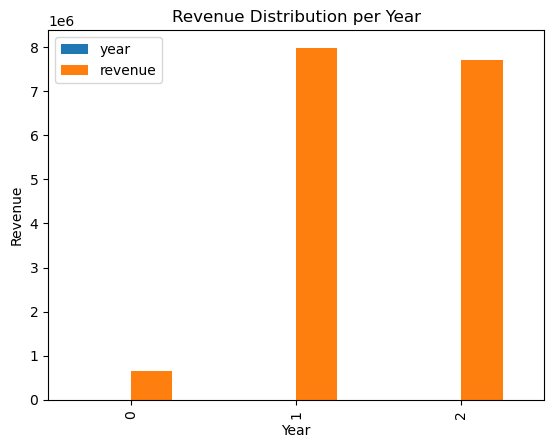

In [31]:
year_rev = df_base.groupby('year')['revenue'].sum().reset_index()
year_rev.plot(kind='bar')
plt.title('Revenue Distribution per Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()

- the total revenue are roughly the same for 2010 (1) and 2011 (2);

Text(0.5, 1.0, 'Monthly Revenue Trend')

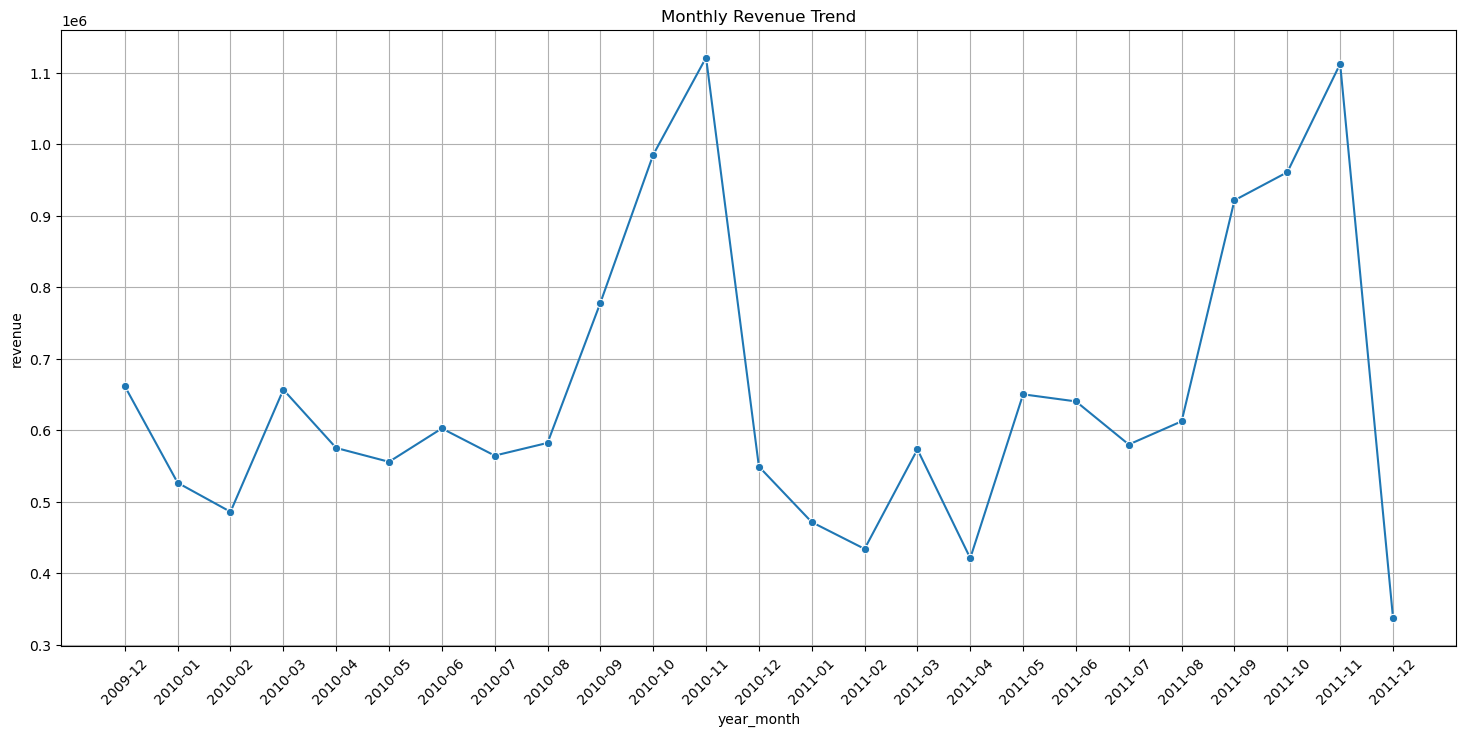

In [32]:
year_month_rev = df_base.groupby(['year','month'])['revenue'].sum().reset_index()
year_month_rev['year_month'] = year_month_rev['year'].astype(str) + '-' + year_month_rev['month'].astype(str).str.zfill(2)
year_month_rev = year_month_rev.sort_values('year_month')

plt.figure(figsize=(18, 8))
sns.lineplot(data=year_month_rev, x='year_month', y='revenue', marker='o')
plt.xticks(rotation=45)
plt.grid()
plt.title('Monthly Revenue Trend')

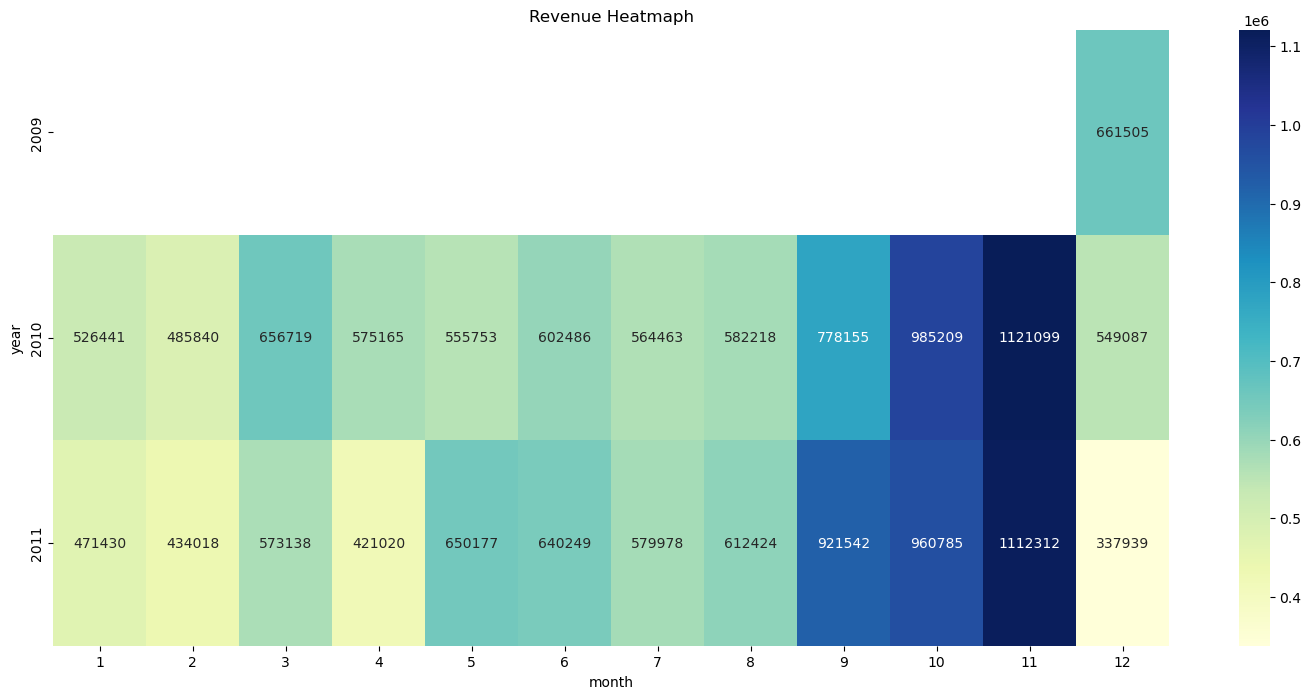

In [33]:
pivot_rev = year_month_rev.pivot(index='year', columns='month', values='revenue')

plt.figure(figsize=(18, 8))
sns.heatmap(pivot_rev, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Revenue Heatmaph')
plt.show()

- see 2 spikes of monthly revenue in Oct-Nov in years 2010 and 2011; can be due to purchases before New Year; (pre-holiday surge)
- see 2 huge drop (to norm) of monthly revenue in Dec in years 2010 and 2011; probably due to the peak; (post-peak exhaustion)

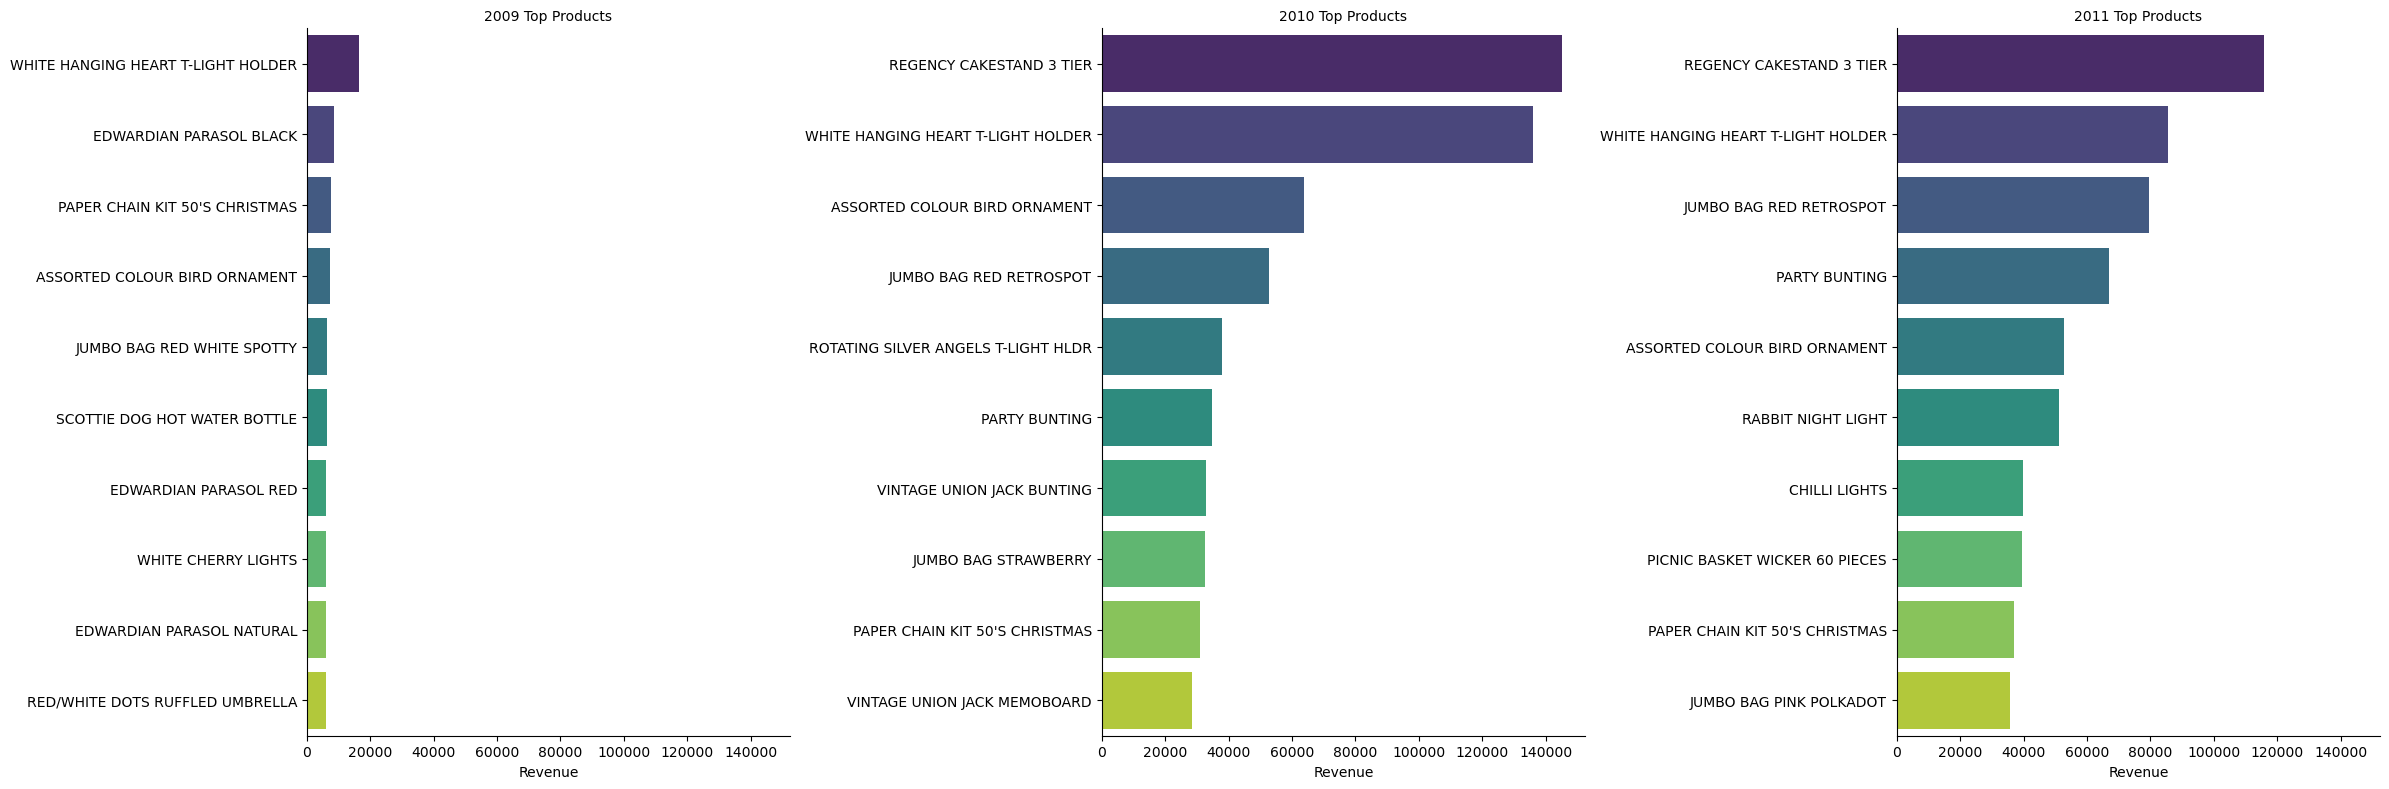

In [34]:
year_product_rev = df_base.groupby(['year', 'stock_code', 'description'])['revenue'].sum().reset_index()
year_product_rev = year_product_rev.sort_values(['year', 'revenue'], ascending=[True, False])

top_10_per_year = year_product_rev.groupby('year').head(10).reset_index()
top_10_per_year = top_10_per_year.drop(columns='index').copy()

g = sns.FacetGrid(top_10_per_year, col="year", col_wrap=3, height=8, aspect=1, sharey=False)

g.map_dataframe(
    sns.barplot, 
    x="revenue", 
    y="description", 
    hue="description",  #
    palette="viridis", 
    legend=False       
)

g.set_titles("{col_name} Top Products")
g.set_axis_labels("Revenue", "")

plt.tight_layout()
plt.show()

-  top 10 bestsellers per year

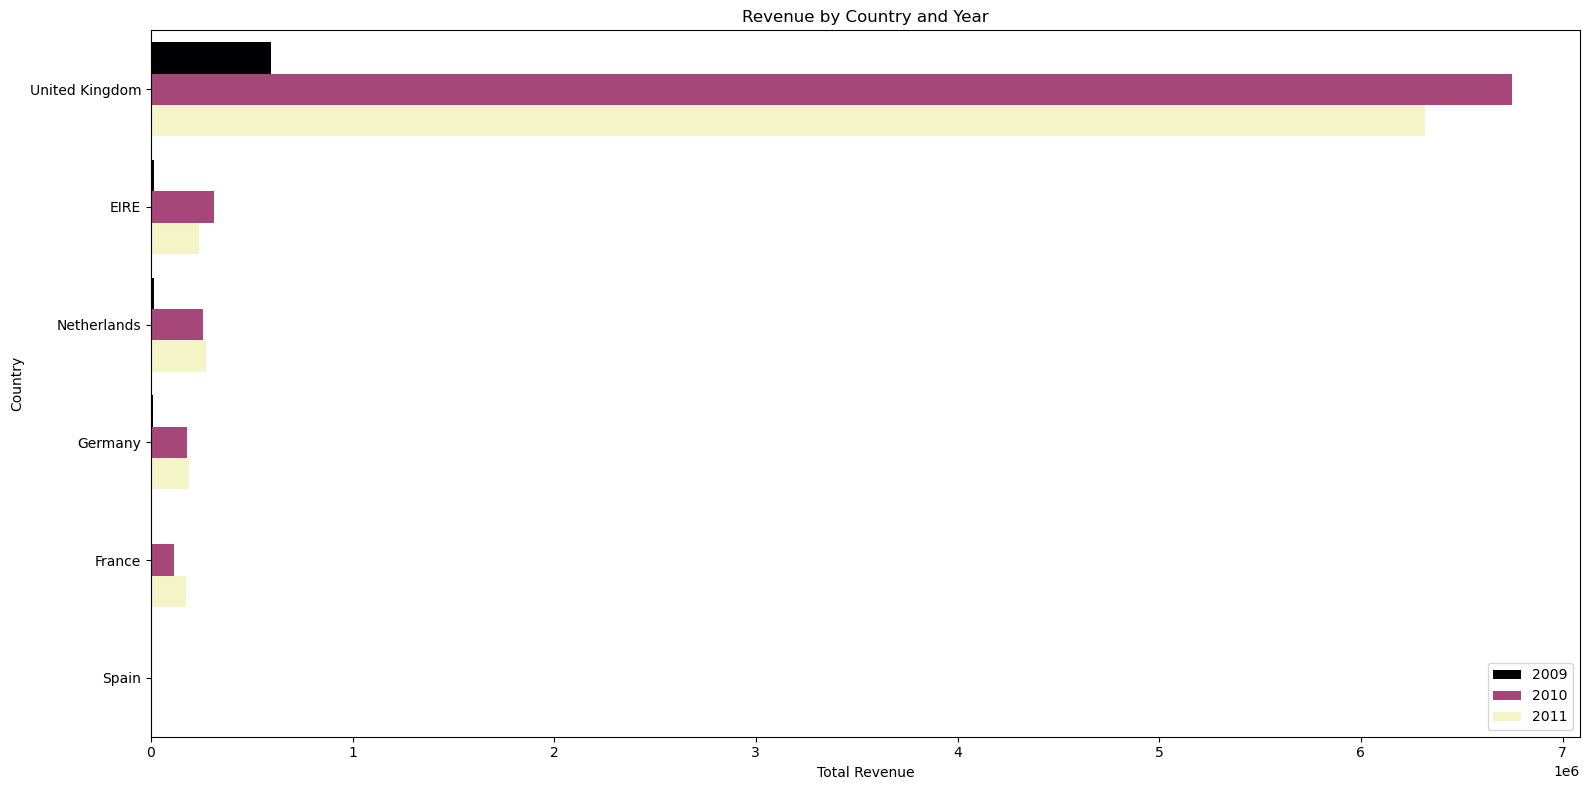

In [35]:
year_country_rev = df_base.groupby(['year', 'country'])['revenue'].sum().reset_index()
year_country_rev.sort_values(by='revenue', ascending=False, inplace=True)
top_5_per_year = year_country_rev.groupby('year').head(5).reset_index()

plt.figure(figsize=(16, 8))

sns.barplot(
    data=top_5_per_year, 
    x='revenue', 
    y='country', 
    hue='year', 
    palette='magma',

)

plt.title('Revenue by Country and Year')
plt.legend(loc='lower right')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

- top 5 contries by revenue per year